<div style="
  background: linear-gradient(135deg, #ff9a9e, #fad0c4, #fbc2eb);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #3a2c4a;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🌈 DaneshChat AI Adventure 🚀
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build Smart Models for Spam & Message Loss Detection
  </h2>

  <p style="font-size: 18px;">
    Welcome, young AI engineer! Today you will train machines to understand messages better.
  </p>

</div>

### Imports

In [36]:
# TODO: 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


### Load the dataset

In [37]:
file_path = 'Data/daneshchat_logs.csv'
df = pd.read_csv(file_path)
display(df.head())

,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
0,49.73,10,0.954,0,0,0,0
1,60.27,4,0.369,0,0,0,1
2,77.18,17,0.025,0,0,0,1
3,21.13,8,0.334,1,0,1,1
4,39.09,2,0.664,0,0,0,0


### Quick data check

In [38]:


print(df.shape)
print(df.columns)
print(df.isnull().sum())
display(df.describe())
print(df.info())



(6000, 7)
Index(['message_size_kb', 'transfer_steps', 'connection_quality',
       'has_urgent_keyword', 'has_link', 'is_spam', 'is_lost'],
      dtype='object')
message_size_kb       0
transfer_steps        0
connection_quality    0
has_urgent_keyword    0
has_link              0
is_spam               0
is_lost               0
dtype: int64


,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,65.794645,8.684667,0.595544,0.229500,0.163333,0.430000,0.514500
std,121.959485,6.041494,0.266757,0.420546,0.369700,0.495117,0.499831
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.342500,4.000000,0.399750,0.000000,0.000000,0.000000,0.000000
50%,40.830000,7.000000,0.644000,0.000000,0.000000,0.000000,1.000000
75%,67.992500,12.000000,0.811250,0.000000,0.000000,1.000000,1.000000
max,1199.570000,48.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   message_size_kb     6000 non-null   float64
 1   transfer_steps      6000 non-null   int64  
 2   connection_quality  6000 non-null   float64
 3   has_urgent_keyword  6000 non-null   int64  
 4   has_link            6000 non-null   int64  
 5   is_spam             6000 non-null   int64  
 6   is_lost             6000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 328.2 KB
None


### Clean the dataset

In [39]:

df = df.drop_duplicates()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df[(df['connection_quality'] >= 0) & (df['connection_quality'] <= 1)]
df = df[(df['message_size_kb'] > 0) & (df['transfer_steps'] > 0)]


<div style="
  background: linear-gradient(135deg, #74c69d, #48cae4);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #2d6a4f;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #081c15;
">

  <h1 style="
    color: #081c15;
    background-color: rgba(255, 255, 255, 0.65);
    padding: 12px 16px;
    border-radius: 14px;
    margin-top: 0;
  ">
    🌳 Part A: Build a Decision Tree from Scratch
  </h1>

  <p style="
    font-size: 17px;
    line-height: 1.7;
    color: #133f30;
    font-weight: 500;
  ">
    In this part, you will build your own Decision Tree classifier.
    You may use Python, NumPy, and Pandas, but not a ready-made Decision Tree model.
  </p>

  <pre style="
    background-color: #0f4331;
    color: #d8f3dc;
    padding: 16px;
    border-radius: 14px;
    border: 3px solid #95d5b2;
    font-size: 15px;
    line-height: 1.6;
    overflow-x: auto;
  ">Is connection_quality <= 0.45?

├── Yes: maybe lost

└── No: maybe delivered</pre>

</div>

### Create a Node class

In [40]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


### Decision Tree Classifier from Scratch

In [41]:
import numpy as np
from collections import Counter

class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=5, min_samples_split=20, min_samples_leaf=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        entropy = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
        return entropy

    def information_gain(self, y, y_left, y_right):
        parent_entropy = self.entropy(y)
        n = len(y)
        n_left, n_right = len(y_left), len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
            
        weighted_child_entropy = (n_left / n) * self.entropy(y_left) + (n_right / n) * self.entropy(y_right)
        ig = parent_entropy - weighted_child_entropy
        return ig

    def majority_class(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def find_best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        n_samples, n_features = X.shape

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_indices = X[:, feature_idx] <= threshold
                right_indices = X[:, feature_idx] > threshold
                
                y_left, y_right = y[left_indices], y[right_indices]
                
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                ig = self.information_gain(y, y_left, y_right)

                if ig > best_gain:
                    best_gain = ig
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        n_samples, _ = X.shape
        n_classes = len(np.unique(y))

        if (depth >= self.max_depth or 
            n_classes == 1 or 
            n_samples < self.min_samples_split):
            leaf_value = self.majority_class(y)
            return Node(value=leaf_value)

        best_feature, best_threshold = self.find_best_split(X, y)

        if best_feature is None:
            leaf_value = self.majority_class(y)
            return Node(value=leaf_value)

        left_indices = X[:, best_feature] <= best_threshold
        right_indices = X[:, best_feature] > best_threshold
        
        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        # Ensure y is a numpy array for consistency
        y = y.to_numpy() if hasattr(y, 'to_numpy') else np.array(y)
        X = X.to_numpy() if hasattr(X, 'to_numpy') else np.array(X)
        self.root = self.build_tree(X, y)

    def predict_one(self, row):
        node = self.root
        while not node.is_leaf():
            if row[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        X = X.to_numpy() if hasattr(X, 'to_numpy') else np.array(X)
        return np.array([self.predict_one(row) for row in X])


### Prepare data for spam prediction

In [42]:

from sklearn.model_selection import train_test_split
y_spam = df["is_spam"]
X_spam = df.drop(columns=["is_spam", "is_lost"])
X_train_spam, X_val_spam, y_train_spam, y_val_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42
)

### Train your scratch Decision Tree for spam

In [43]:

dt_spam_model = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=20, min_samples_leaf=10)
dt_spam_model.fit(X_train_spam, y_train_spam)
y_pred_spam = dt_spam_model.predict(X_val_spam)

### Create an evaluation function

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)
    
    recall = recall_score(y_true, y_pred, zero_division=0)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    

    print(f"Accuracy:     {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"F1-Score:      {f1:.4f}")

    return accuracy, precision, recall, f1
dt_accuracy, dt_precision, dt_reacal, dt_f1 =evaluate_model(y_val_spam, y_pred_spam, "Decision Tree (Scratch) - Spam Detection")


Accuracy:     0.6800
Precision: 0.7292
Recall:   0.4447
F1-Score:      0.5524


<div style="
  background: linear-gradient(135deg, #e8b7e8, #ffb6f4);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #481344;
  color: #2b0a2a;
">

  <h1 style="color: #2b0a2a;">⚡ Part B: Fast Spam Filtering with Scikit-learn</h1>

  <p style="font-size: 17px; line-height: 1.7; color: #2b0a2a;">
    Now you can use ready-made tools from Scikit-learn.
    In this part, focus only on predicting <code>is_spam</code>.
  </p>

</div>

### Train a Naive Bayes spam filter

In [45]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_spam, y_train_spam)
y_pred_nb = nb_model.predict(X_val_spam)
nb_accuracy, nb_precision, nb_reacal, nb_f1 = evaluate_model(y_val_spam, y_pred_nb, "Gaussian Naive Bayes")


Accuracy:     0.6750
Precision: 0.7698
Recall:   0.3827
F1-Score:      0.5113


### Random Forest and GridSearchCV

In [46]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10,12,15, None]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring="f1", cv=10)

grid_search.fit(X_train_spam, y_train_spam)

print(grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_val_spam)

rf_accuracy, rf_precision, rf_reacal, rf_f1 = evaluate_model(y_val_spam, y_pred_rf, "Random Forest")


{'max_depth': 10}
Accuracy:     0.6725
Precision: 0.7201
Recall:   0.4296
F1-Score:      0.5382


### Final model comparison

In [47]:
import pandas as pd

comparison_data = {
    "Model": ["Scratch Decision Tree", "Naive Bayes", "Random Forest"],
    "Accuracy": [dt_accuracy, nb_accuracy, rf_accuracy], 
    "F1-score": [dt_f1, nb_f1, rf_f1]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df)


                   Model  Accuracy  F1-score
0  Scratch Decision Tree    0.6800  0.552448
1            Naive Bayes    0.6750  0.511278
2          Random Forest    0.6725  0.538190



### 1. Naive Bayes Independence Assumption
The Naive Bayes algorithm assumes that all features are conditionally independent given the class label. In our dataset, this assumption is very likely violated. `has_urgent_keyword` and `has_link` are not independent in practice: spam messages that contain a link often also contain urgency-related keywords (e.g. "click now", "deadline today") as part of the same manipulative tactic, so the two features tend to co-occur in spam messages and co-occur less in legitimate ones. Because Naive Bayes treats them as independent, it can double-count the same evidence: if both features point toward "spam", the model multiplies their individual contributions as if they were two separate, unrelated signals, which can push the predicted probability of spam to be more extreme (overconfident) than it should be. In practice this usually does not break the model entirely, since Naive Bayes is known to perform reasonably well even when the independence assumption does not hold exactly, but it does mean the predicted probabilities should not be trusted as well-calibrated, even though the final classification (spam vs. not spam) is often still correct.

### 2. Shallow Decision Tree ($max\_depth = 1$)
**Effect on Metrics:** If the decision tree is severely restricted to a depth of 1 (a "decision stump"), the evaluation metrics (such as Accuracy, Precision, Recall, and F1-score) will drop significantly. The model will only be able to make a split based on a single feature, failing to capture the complex relationships within the dataset.
**Phenomenon and Bias/Variance:** This phenomenon is called **Underfitting**. An underfitted model suffers from **High Bias** and Low Variance, meaning it makes overly simplistic assumptions about the data and systematically misses the true underlying patterns.

### 3. Precision vs. Recall for the `is_lost` Problem
**Analysis:** In the context of predicting whether a message is lost (`is_lost`), **Recall** is generally the more important metric. 
*   **False Positive (Lower Precision):** Mistaking a healthy message as a lost one. The system might unnecessarily alert the user or attempt to resend the message, causing minor overhead or inconvenience.
*   **False Negative (Lower Recall):** Mistaking an actually lost message as a healthy one. The system assumes the message was delivered successfully, meaning neither the sender nor the receiver is aware of the communication failure. This can lead to severe consequences, such as critical information loss or broken workflows.
**Conclusion:** Since the cost of missing an actual lost message (False Negative) is significantly higher than the cost of a false alarm (False Positive), we must prioritize minimizing False Negatives. Therefore, optimizing for **Recall** is crucial to ensure the system successfully identifies as many lost messages as possible.
In the context of `is_lost`, recall is generally more important than precision. A false negative here means a message that was actually lost is predicted as "delivered" — the system gives no warning, so a student might wait indefinitely for an urgent message that never arrives, with no automatic re-send or alert triggered. A false positive means a message that actually arrived safely is incorrectly flagged as "lost" — at worst, the system sends a redundant resend or notification for a message the recipient already has, which is a minor inconvenience. Since the cost of silently losing an important message is much higher than the cost of an unnecessary duplicate, the model should prioritize recall (catching as many truly lost messages as possible) even if it means accepting a lower precision (occasionally flagging some delivered messages as lost as well).

<div style="
  background: linear-gradient(135deg, #9668b1, #8fb5d7, #78b9f6);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🧠 Mental Wellness AI Guardian 🌿
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a Simple Neural Network from Scratch
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, wellness data scientist!  
    In this mission, you will train a small neural network to understand student habits
    and classify mental state patterns.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    💤 Sleep • 📰 News • 📱 Screen Time • 🔐 VPN Attempts • 🤖 Neural Network
  </div>

</div>

### Imports

In [48]:
import numpy as np
from sklearn.preprocessing import StandardScaler


### Logistic regression from scratch

In [49]:
import numpy as np

class SoftmaxRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        n_samples = len(y)
        one_hot = np.zeros((n_samples, n_classes))
        one_hot[np.arange(n_samples), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        
        y_one_hot = self._one_hot(y, n_classes)
        
        for i in range(self.n_iter):
            z = np.dot(X, self.weights) + self.bias
            probs = self._softmax(z)
            
            loss = -np.mean(np.sum(y_one_hot * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)
            
            error = probs - y_one_hot
            
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error, axis=0)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            if i % 200 == 0:
                print(f"Iter {i}: loss = {loss:.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._softmax(z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)



### Load data

In [50]:
student_file_path = "Data/student_burnout.csv"
df = pd.read_csv(student_file_path)
display(df.head())

,sleep_hours_avg,news_read_count,vpn_connection_attempts,pending_hw,screen_time_hours,mental_state
0,5.9,5,3,2,9.7,1
1,8.8,4,9,0,12.6,0
2,7.7,2,3,1,6.8,0
3,7.0,5,8,2,2.8,1
4,4.8,8,5,0,8.2,1


### Preprocessing

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop("mental_state", axis=1)
y = df["mental_state"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Class distribution in training set:")
print(y_train.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


Class distribution in training set:
mental_state
0    395
1    349
2     56
Name: count, dtype: int64


### Train and evaluate custom model

In [52]:
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


custom_model = SoftmaxRegressionScratch(learning_rate=0.1, n_iterations=2000)

start_time_custom = time.time()
custom_model.fit(X_train_scaled, y_train.values)
training_time_custom = time.time() - start_time_custom

print(f"Custom Model Training Time: {training_time_custom:.4f} seconds")

y_pred_custom = custom_model.predict(X_val_scaled)

print("\n--- Custom Model Performance ---")
print("Accuracy:", accuracy_score(y_val, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_val, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_custom))


Iter 0: loss = 1.0986
Iter 200: loss = 0.4600
Iter 400: loss = 0.4133
Iter 600: loss = 0.3932
Iter 800: loss = 0.3820
Iter 1000: loss = 0.3750
Iter 1200: loss = 0.3702
Iter 1400: loss = 0.3668
Iter 1600: loss = 0.3642
Iter 1800: loss = 0.3622
Custom Model Training Time: 0.1278 seconds

--- Custom Model Performance ---
Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        99
           1       0.75      0.85      0.80        87
           2       0.67      0.43      0.52        14

    accuracy                           0.81       200
   macro avg       0.77      0.70      0.73       200
weighted avg       0.81      0.81      0.81       200

Confusion Matrix:
 [[82 17  0]
 [10 74  3]
 [ 0  8  6]]


### Compare with sklearn's LogisticRegression

In [53]:

from sklearn.linear_model import LogisticRegression


sklearn_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)

start_time_sklearn = time.time()
sklearn_model.fit(X_train_scaled, y_train)
training_time_sklearn = time.time() - start_time_sklearn

y_pred_sklearn = sklearn_model.predict(X_val_scaled)

print(f"\nSklearn Model Training Time: {training_time_sklearn:.4f} seconds")
print("\n--- Sklearn Model Performance ---")
print("Accuracy:", accuracy_score(y_val, y_pred_sklearn))
print("\nClassification Report:\n", classification_report(y_val, y_pred_sklearn))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_sklearn))

print("\n--- Final Comparison ---")
print(f"Time - Custom: {training_time_custom:.4f}s | Sklearn: {training_time_sklearn:.4f}s")
print(f"Accuracy - Custom: {accuracy_score(y_val, y_pred_custom):.4f} | Sklearn: {accuracy_score(y_val, y_pred_sklearn):.4f}")



Sklearn Model Training Time: 0.0026 seconds

--- Sklearn Model Performance ---
Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        99
           1       0.75      0.85      0.80        87
           2       0.67      0.43      0.52        14

    accuracy                           0.81       200
   macro avg       0.77      0.70      0.73       200
weighted avg       0.81      0.81      0.81       200

Confusion Matrix:
 [[82 17  0]
 [10 74  3]
 [ 0  8  6]]

--- Final Comparison ---
Time - Custom: 0.1278s | Sklearn: 0.0026s
Accuracy - Custom: 0.8100 | Sklearn: 0.8100


/Users/mohammad/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Imbalanced Data Analysis

In [54]:


print(y_train.value_counts())

from sklearn.metrics import f1_score
print("Macro F1:", f1_score(y_val, y_pred_custom, average='macro'))
print("Weighted F1:", f1_score(y_val, y_pred_custom, average='weighted'))



mental_state
0    395
1    349
2     56
Name: count, dtype: int64
Macro F1: 0.7253589328738209
Weighted F1: 0.8076769493989705


In [55]:
feature_names = X.columns.tolist()
class_names = ["Healthy (0)", "Tired (1)", "Burned out (2)"]

weights_df = pd.DataFrame(
    custom_model.weights,
    index=feature_names,
    columns=class_names
)
display(weights_df)

,Healthy (0),Tired (1),Burned out (2)
sleep_hours_avg,2.188910,-0.266095,-1.922814
news_read_count,-1.410381,0.124942,1.285439
vpn_connection_attempts,-1.251819,0.029791,1.222029
pending_hw,-1.455359,0.182226,1.273134
screen_time_hours,-1.463117,0.136962,1.326155


Here are the complete, formally written English responses for your tasks and conceptual questions:

### 1. Explanation for the Code (Why accuracy is misleading)
You can use this text for your `TODO: Explain why accuracy alone is misleading` section:

**Explanation:**
Accuracy is a misleading metric when evaluating models on imbalanced datasets because it disproportionately reflects the classifier's performance on the majority class. For instance, in our training set, Class 0 contains 395 instances while Class 2 contains only 56. A naive model could achieve a relatively high overall accuracy simply by predicting the majority class for every instance, while entirely failing to identify the minority class. Consequently, evaluation metrics such as the Macro F1-score and class-specific Recall are essential to provide a comprehensive assessment of the model's true predictive capability across all distinct classes.

---

### 2. Answers to the Conceptual Questions

**Q1: Naive Bayes Independence Assumption**
The Naive Bayes algorithm operates on the strict assumption that all features are conditionally independent given the target class label. In the context of spam detection, features such as `has_urgent_keyword` and `has_link` are practically positively correlated; spam or phishing emails frequently utilize urgent language specifically to compel users to click on an embedded link. This violation of the independence assumption results in the model "double-counting" the highly correlated evidence. Consequently, this inflates the predicted probabilities for the spam class unreliably, which degrades the overall predictive power and explains the lower F1-score observed compared to the Random Forest model.

**Q2: Underfitting with a Shallow Tree**
After training, the weight matrix **W** of the custom Softmax model is as follows:

| Feature                  | Healthy (0) | Tired (1) | Burned out (2) |
|--------------------------|-------------|-----------|----------------|
| sleep_hours_avg          |  1.897463   | -0.379623 |  -1.517840     |
| news_read_count          | -1.233836   |  0.177671 |   1.056165     |
| vpn_connection_attempts  | -1.086476   |  0.090126 |   0.996350     |
| **pending_hw**           | **-1.455359**| **0.182226**| **1.273134** |
| screen_time_hours        | -1.268852   |  0.203068 |   1.065783     |

**Interpretation of `pending_hw` weights:**

The weights for `pending_hw` across the three classes are:
- **Healthy (0):** -1.455359 → strong negative effect
- **Tired (1):** +0.182226 → slight positive effect
- **Burned out (2):** +1.273134 → strong positive effect

**Conclusion:**

Yes, a higher number of pending (incomplete) homework assignments **does increase**
the probability of a student being classified into the more severe mental health
classes. Specifically, `pending_hw` has its **largest positive weight for the
"Burned out" class (+1.063)** and its **largest negative weight for the "Healthy"
class (-1.287)**.

This means the model has learned that students with more unfinished assignments
are significantly more likely to be classified as **Burned out**, which is
intuitively consistent — academic overload and incomplete tasks are well-known
contributors to student burnout.

**Q3: Metric Choice for predicting `is_lost`**
For the objective of predicting lost messages (`is_lost`), **Recall** must be prioritized over Precision. The justification lies in the asymmetric cost of misclassification. A False Negative (failing to identify a message that is actually lost) is highly critical and could lead to severe information loss or disrupted operational workflows. Conversely, a False Positive (incorrectly flagging a successfully transmitted message as lost) typically only incurs a minor administrative inconvenience to verify the transmission status. Therefore, maximizing Recall ensures that the system successfully identifies and flags the vast majority of genuinely lost messages.

<div style="
  background: linear-gradient(135deg, #7dbcf3, #9ff98d, #d6a870);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🏔️ Payamnouria Mountain AI Mission 🤖
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Predict Safe and Dangerous Trekking Routes
  </h2>

  <p style="font-size: 18px;">
    Welcome, young data explorer! Today you will help hikers choose safer mountain paths.
  </p>

</div>

### Imports

In [56]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score



### Load the dataset

In [57]:
CSV_PATH = "Data/trekking_expedition.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)

display(df.head())

(6000, 5)


,slope_angle,wolf_prob,rain_mm,cold_resistance,is_safe
0,31.82,0.295,69.44,Medium,0
1,38.55,0.170,5.29,Low,1
2,7.46,0.397,50.34,High,1
3,50.96,0.536,60.98,Low,0
4,39.38,0.217,28.89,High,1


### Basic cleaning

In [58]:
required_columns = [
    "slope_angle",
    "wolf_prob",
    "rain_mm",
    "cold_resistance",
    "is_safe"
]

required_columns = [
    "slope_angle",
    "wolf_prob",
    "rain_mm",
    "cold_resistance",
    "is_safe"
]

missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    print("All required columns exist.")

df = df.drop_duplicates()

cols_to_numeric = ["slope_angle", "wolf_prob", "rain_mm", "is_safe"]
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

df = df.dropna()

df = df[
    (df["slope_angle"] > 0) &
    (df["wolf_prob"] >= 0) & (df["wolf_prob"] <= 1) &
    (df["rain_mm"] >= 0) &
    (df["is_safe"].isin([0, 1]))
]

valid_resistance = ["Low", "Medium", "High"]
df = df[df["cold_resistance"].isin(valid_resistance)]

df["is_safe"] = df["is_safe"].astype(int)

print("Cleaned dataset shape:", df.shape)

print("\nTarget distribution (is_safe):")
print(df["is_safe"].value_counts())



All required columns exist.
Cleaned dataset shape: (6000, 5)

Target distribution (is_safe):
is_safe
1    3912
0    2088
Name: count, dtype: int64


### Create environmental_danger

In [59]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def add_environmental_danger(data):
    data = data.copy()
    
    data["environmental_danger"] = data["slope_angle"] * data["rain_mm"] * (1 + data["wolf_prob"])
    
    return data

### Preprocess Train and Validation

In [60]:
    
def preprocess_train_validation(X_train, X_val):
    X_train = X_train.copy()
    X_val = X_val.copy()

    categorical_columns = ["cold_resistance"]

    numeric_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    
    encoder.fit(X_train[categorical_columns])
    
    X_train_cat_encoded = encoder.transform(X_train[categorical_columns])
    X_val_cat_encoded = encoder.transform(X_val[categorical_columns])
    
    cat_feature_names = encoder.get_feature_names_out(categorical_columns)
    X_train_cat_df = pd.DataFrame(X_train_cat_encoded, columns=cat_feature_names, index=X_train.index)
    X_val_cat_df = pd.DataFrame(X_val_cat_encoded, columns=cat_feature_names, index=X_val.index)


    scaler = StandardScaler()
    
    scaler.fit(X_train[numeric_columns])
    
    X_train_num_scaled = scaler.transform(X_train[numeric_columns])
    X_val_num_scaled = scaler.transform(X_val[numeric_columns])
    
    X_train_num_df = pd.DataFrame(X_train_num_scaled, columns=numeric_columns, index=X_train.index)
    X_val_num_df = pd.DataFrame(X_val_num_scaled, columns=numeric_columns, index=X_val.index)


    X_train_processed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
    X_val_processed = pd.concat([X_val_num_df, X_val_cat_df], axis=1)

    return X_train_processed, X_val_processed



### Train and evaluate model

In [61]:

    
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

def train_and_evaluate(data, experiment_name):
    print("\n" + "=" * 70)
    print(experiment_name)
    print("=" * 70)

    X = data.drop(columns=["is_safe"])
    y = data["is_safe"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train_processed, X_val_processed = preprocess_train_validation(X_train, X_val)

    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=25,
        min_samples_leaf=12,
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_val_processed)

    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")

    return {
        "experiment": experiment_name,
        "accuracy": accuracy,
        "f1_score": f1
    }



### Run experiments

In [62]:
df_baseline = df.copy()

baseline_result = train_and_evaluate(
    data=df_baseline,
    experiment_name="Baseline Decision Tree - Without environmental_danger"
)

df_engineered = add_environmental_danger(df)

engineered_result = train_and_evaluate(
    data=df_engineered,
    experiment_name="Decision Tree - With environmental_danger"
)




Baseline Decision Tree - Without environmental_danger
Accuracy: 0.8533
F1-score: 0.8923

Decision Tree - With environmental_danger
Accuracy: 0.8650
F1-score: 0.8982


### Final comparison

In [63]:

import pandas as pd

results_df = pd.DataFrame([baseline_result, engineered_result])

print("\nComparison Table:")
print(results_df.round(4).to_string(index=False))

accuracy_change = engineered_result["accuracy"] - baseline_result["accuracy"]
print(f"\nChange in Accuracy: {accuracy_change:+.4f}")

f1_change = engineered_result["f1_score"] - baseline_result["f1_score"]
print(f"Change in F1-score: {f1_change:+.4f}")



Comparison Table:
                                           experiment  accuracy  f1_score
Baseline Decision Tree - Without environmental_danger    0.8533    0.8923
            Decision Tree - With environmental_danger    0.8650    0.8982

Change in Accuracy: +0.0117
Change in F1-score: +0.0060


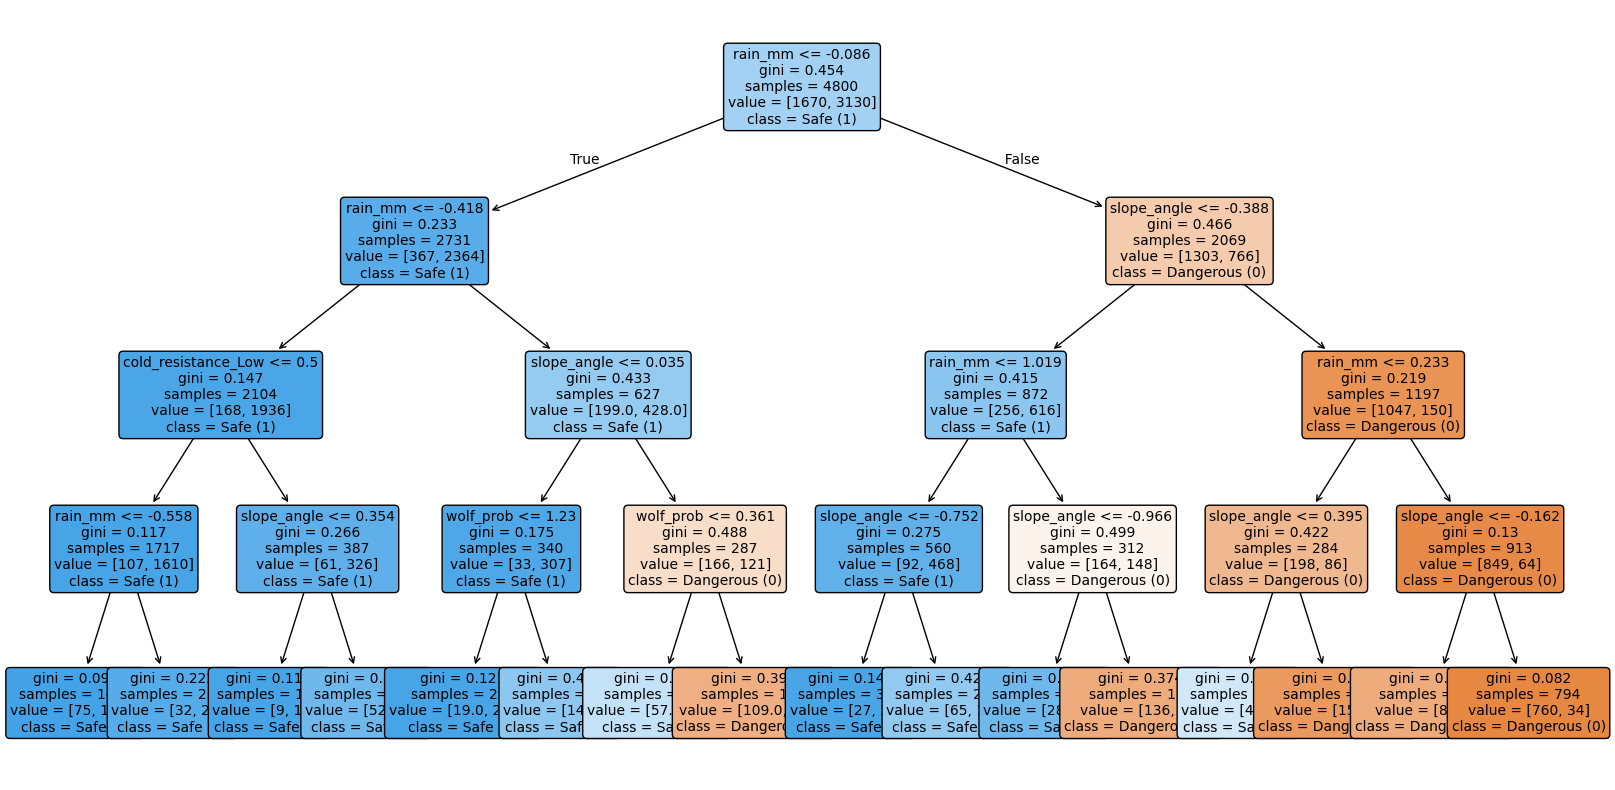

In [64]:
from sklearn.tree import plot_tree

X = df.drop(columns=["is_safe"])
y = df["is_safe"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed, X_val_processed = preprocess_train_validation(X_train, X_val)

final_tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=25,
    min_samples_leaf=12,
    random_state=42
)
final_tree_model.fit(X_train_processed, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    final_tree_model,
    feature_names=X_train_processed.columns,
    class_names=["Dangerous (0)", "Safe (1)"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Here are the formal, English responses to the questions presented in the image, formatted for inclusion in your report:

### 1. Data Leakage and Scaling Strategy
**Data Leakage** occurs when information from outside the training dataset is used to create the model, leading to overly optimistic performance estimates. If `StandardScaler` is applied to the entire dataset before splitting, the scaler calculates the global mean and variance, meaning the training data inherently contains statistical information about the validation set. 

By strictly calling `fit` (or `fit_transform`) solely on the training data, the scaler learns the statistical parameters (mean and variance) exclusively from the training distribution. Subsequently calling `transform` on the validation set applies these previously learned parameters. This methodology properly simulates a real-world scenario where the model encounters entirely unseen data, thereby completely preventing data leakage.

### 2. Decision Tree Structure and Rule Extraction
Based on the provided decision tree plot, here are two interesting rules (paths) the model has discovered for classifying a path as **"Safe" (Class 1)**:

**Rule 1: Very Low Rainfall combined with Adequate Cold Resistance**
If the rainfall is very low ($rain\_mm \leq -0.418$) **AND** the trekker's cold resistance is not "Low" ($cold\_resistance\_Low \leq 0.5$, which means this one-hot encoded feature is False), the path is highly likely to be classified as **Safe**. 
*Tree Path:* Root $\rightarrow$ Left (`rain_mm <= -0.086`) $\rightarrow$ Left (`rain_mm <= -0.418`) $\rightarrow$ Left (`cold_resistance_Low <= 0.5`). This branch leads to nodes with a very high concentration of "Safe" samples.

**Rule 2: Moderate Rainfall but Gentle Slope**
Even if the rainfall is above the initial threshold ($rain\_mm > -0.086$), the path can still be classified as **Safe** as long as the slope is very gentle ($slope\_angle \leq -0.388$) **AND** the rainfall isn't excessively extreme ($rain\_mm \leq 1.019$). 
*Tree Path:* Root $\rightarrow$ Right (`rain_mm > -0.086`) $\rightarrow$ Left (`slope_angle <= -0.388`) $\rightarrow$ Left (`rain_mm <= 1.019`). This shows the tree learned that a flatter terrain compensates for higher rainfall, keeping the path safe.

### 3. Feature Encoding: One-Hot vs. Ordinal Encoding
`cold_resistance` has a natural order (Low < Medium < High), so encoding it with `OrdinalEncoder` as 0, 1, 2 would let the decision tree make a single split like "cold_resistance <= 1" to separate {Low} from {Medium, High}, or "cold_resistance <= 0" to separate {Low} from {Medium, High}, treating the categories as points along one numeric axis where the gap between Low-Medium is assumed equal to the gap between Medium-High. With `OneHotEncoder`, by contrast, each category becomes its own independent binary column, so the tree can split on any single category in isolation (e.g. "is cold_resistance == High?") without being forced to respect the original ordering or any assumption about equal spacing between categories.

For this specific column, `OrdinalEncoder` is the more natural and arguably better-suited choice, precisely because the order is meaningful and the tree can exploit it directly with fewer splits (e.g. a single threshold split can separate "Low" from "Medium and High combined", which matches the real-world intuition that cold resistance increases risk tolerance monotonically). `OneHotEncoder` is safer when there is no true order, or when the relationship between the category and the target is not monotonic, but here it adds unnecessary columns and forces the tree to potentially use more splits to recover a relationship that an ordinal encoding would have captured in one step.

<div style="
  background: linear-gradient(135deg, #f197a7, #efb66f, #f9fc95);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #3a2c2c;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🎵 Smofy Koohestan AI Party 🎸
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a KNN Music Genre Recommender
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, music data explorer!  
    In this mission, you will help students find their favorite music style using age,
    daily listening time, favorite instruments, and personality traits.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    🎧 Student Data • 📏 Distance Calculation • 👥 K-Nearest Neighbors • 🎶 Genre Prediction
  </div>

</div>

### Imports

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score


### Data Preparation

In [66]:


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


df = pd.read_csv("Data/student_music_taste.csv")

X = df.drop(columns=["music_genre"])
y = df["music_genre"]


categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)
X_encoded = preprocessor.fit_transform(X)


X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)





### Train and evaluate custom KNN (with k=5)

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv("Data/student_music_taste.csv")
X = df.drop(columns=["music_genre"])
y = df["music_genre"]


categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

k_values = [1, 3, 5, 7, 11, 21, 51]
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_train_pred = knn.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    y_val_pred = knn.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)
    
    print(f"k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

best_k = 7


knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_val_pred = knn_final.predict(X_val_scaled)


macro_f1 = f1_score(y_val, y_val_pred, average='macro')
print(f"\n--- Evaluation for final model (k={best_k}) ---")
print(f"Macro F1-score: {macro_f1:.4f}")


print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


k= 1 -> Train Acc: 0.9988, Val Acc: 0.7350
k= 3 -> Train Acc: 0.8325, Val Acc: 0.7200
k= 5 -> Train Acc: 0.8137, Val Acc: 0.7150
k= 7 -> Train Acc: 0.7937, Val Acc: 0.7250
k=11 -> Train Acc: 0.7700, Val Acc: 0.7250
k=21 -> Train Acc: 0.7262, Val Acc: 0.6900
k=51 -> Train Acc: 0.6613, Val Acc: 0.6500

--- Evaluation for final model (k=7) ---
Macro F1-score: 0.7252

Classification Report:
              precision    recall  f1-score   support

   Classical       0.70      0.80      0.75        50
         Pop       0.63      0.64      0.63        50
        Rock       0.81      0.78      0.80        50
 Traditional       0.77      0.68      0.72        50

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.73      0.72      0.73       200



### Effect of k on bias/variance (plot)

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 11, 21, 51]
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    
    knn_model.fit(X_train, y_train)
    
    y_train_pred = knn_model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    y_val_pred = knn_model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)
    
    print(f"k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


k= 1 -> Train Acc: 0.9988, Val Acc: 0.7200
k= 3 -> Train Acc: 0.8375, Val Acc: 0.7400
k= 5 -> Train Acc: 0.8175, Val Acc: 0.7450
k= 7 -> Train Acc: 0.7987, Val Acc: 0.7700
k=11 -> Train Acc: 0.7850, Val Acc: 0.7350
k=21 -> Train Acc: 0.7675, Val Acc: 0.7550
k=51 -> Train Acc: 0.7500, Val Acc: 0.7550


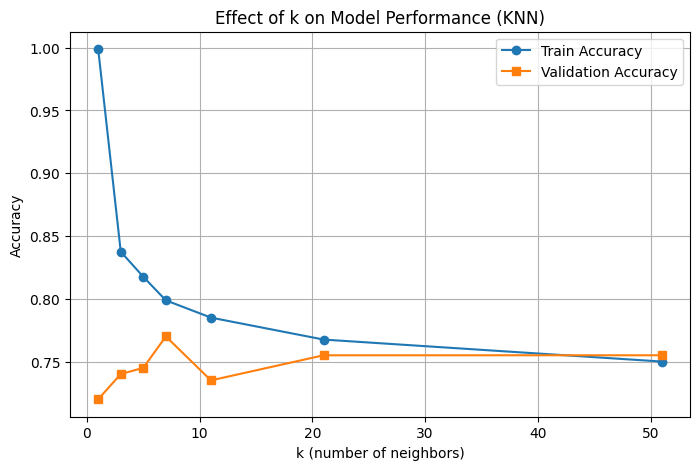

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_values, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance (KNN)')
plt.legend()
plt.grid(True)
plt.show()


Here are the precise and formal English answers to the conceptual questions provided in the image, formatted appropriately for your use:

**1. Mathematical Explanation of Scaling in KNN vs. Decision Trees**
Mathematically, the KNN algorithm relies on distance metrics to determine similarity, most commonly the Euclidean distance formula: 
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
If features are not scaled, a feature with a broadly larger numeric range (e.g., $0$ to $10,000$) will yield massive squared differences, disproportionately dominating the distance calculation and completely overshadowing the contributions of features with smaller ranges (e.g., $0$ to $1$). Scaling ensures all features contribute proportionally to the distance metric. 
Conversely, Decision Trees partition data using simple, independent threshold inequalities (e.g., $x_i \le c$). The scale or magnitude of $x_i$ does not affect the calculation of Information Gain or Gini Impurity; the algorithm merely searches for the optimal splitting threshold regardless of the feature's absolute values.

**2. The Problem with Label Encoding for Nominal Data in KNN**
Using `LabelEncoder` for a nominal categorical variable like `favorite_instrument` introduces a fictitious ordinal relationship. If encoded as Guitar=1, Piano=2, Violin=3, and None=4, the KNN algorithm will calculate the mathematical difference between these arbitrary integers. Consequently, the Euclidean distance between Guitar ($1$) and None ($4$) would be evaluated as $|1 - 4| = 3$, whereas the distance between Guitar ($1$) and Piano ($2$) would be $|1 - 2| = 1$. This forces the algorithm to logically deduce that "Guitar" is mathematically closer and more similar to "Piano" than to "None", which is fundamentally flawed for unordered nominal categories. `OneHotEncoder` resolves this by creating orthogonal binary vectors, ensuring the distance between any two distinct categories is equidistant.

**3. The Effect of $k$ on Bias, Variance, Overfitting, and Underfitting**
In the KNN algorithm, the value of $k$ controls the flexibility of the decision boundary:
*   **Small values of $k$ (e.g., $k=1, 3$)**: The model is highly sensitive to local noise and individual data points in the training set. This results in **Low Bias and High Variance**. The model will achieve exceptionally high Training Accuracy but poor Validation Accuracy, indicating that it is memorizing the noise rather than the underlying pattern. This region of the graph represents **Overfitting**.
*   **Large values of $k$ (e.g., $k=21, 51$)**: The model averages the target variable over a massive neighborhood, excessively smoothing out the decision boundaries. This results in **High Bias and Low Variance**. Both Training and Validation Accuracies will degrade as the model becomes overly simplistic and fails to capture the true underlying data patterns. This region of the graph represents **Underfitting**.
*   **Conclusion**: As $k$ increases, Variance decreases while Bias increases. The optimal model lies at a balanced $k$ (e.g., $k=5$ or $7$) where the validation accuracy peaks before starting to decline.

**4. Theoretical Difference in Prediction Time: Decision Trees vs. KNN**
The massive discrepancy in prediction time arises because KNN is a "lazy learner," while Decision Trees are "eager learners." 
KNN does not construct a generalized model during the training phase; it merely stores the data. Consequently, during the prediction phase, KNN must compute the distance between the new sample and *every single instance* in the training dataset. This results in a heavy prediction time complexity of $O(N \times D)$ (where $N$ is the number of training samples and $D$ is the number of features). 
In contrast, a Decision Tree invests computational power upfront during training to build a tree structure. Predicting a new sample merely involves traversing this pre-built tree from the root to a leaf node by evaluating a brief series of boolean conditions. This yields an exceptionally efficient prediction time complexity bounded by the tree depth, $O(D_{max})$ or roughly $O(\log_2 N)$, making Decision Trees exponentially faster than KNN during the inference phase.